# Diagnostic Accuracy Measures in Clinical Epidemiology

**Authors:** Renato Carneiro de Freitas Chaves, Tiago Mendonça dos Santos, Thiago Domingos Corrêa  

## 1. Purpose

This notebook demonstrates how to calculate and interpret the following diagnostic and prognostic performance measures:

1. Sensitivity
2. Specificity
3. Positive and negative predictive values
4. Positive and negative likelihood ratios
5. Area under the receiver operating characteristic curve (AUC)

The analysis uses the following variables:

- `outcome`: reference outcome (`0 = alive`, `1 = death`)
- `vasopressor`: binary index marker (`0 = no`, `1 = yes`)
- `saps_3`: continuous severity score for ROC/AUC analysis

The event of interest is **hospital death**.

Because vasopressor use is not a diagnostic test in the usual sense, the binary measures should be interpreted as **prognostic classification measures** for hospital death, not as evidence that vasopressors cause death.

## 2) Required Libraries

This notebook uses standard scientific Python libraries.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import norm

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

## 3) Data Import (Excel)

This guide uses the Excel file **`data.xlsx`** with a sheet named **`Data`**.

- If `data.xlsx` is in the same folder as this notebook, you can keep the path as `"data.xlsx"`.
- Otherwise, replace with the full path to your file.


In [5]:
# Update the path if needed
excel_path = "data.xlsx"
sheet_name = "Data"

data = pd.read_excel(excel_path, sheet_name=sheet_name)

# Quick inspection
data.head(), data.shape

(   patient  group  center follow_up_start follow_up_end  follow_up_days  \
 0        1      1       1      2022-06-08    2023-10-10             489   
 1        2      1       1      2022-06-28    2023-08-24             422   
 2        3      1       1      2022-01-14    2022-11-02             292   
 3        4      1       1      2022-06-19    2024-04-05             656   
 4        5      1       1      2022-02-19    2023-01-15             330   
 
    follow_up_years  age  platelet  hemoglobin  creatinine  hypertension  \
 0            1.339   19       229        15.3         0.8             0   
 1            1.155   24       221        14.8         0.8             0   
 2            0.799   25       219        14.4         0.9             0   
 3            1.796   26       217        14.3         0.9             0   
 4            0.903   27       214        13.8         0.9             1   
 
    diabetes  heart_failure  smoking  chronic_kidney_disease  cancer  stroke  \
 0  

## 4) Confirm Required Variables

For the requested calculations, the dataset must contain:

- `outcome` (`0 = alive`, `1 = death`)
- `vasopressor` (`0 = no`, `1 = yes`)
- `saps_3` for ROC/AUC analysis

In [6]:
required_columns = ["outcome", "vasopressor", "saps_3"]
missing_columns = [column for column in required_columns if column not in data.columns]

if missing_columns:
    raise ValueError(f"The dataset is missing the following required columns: {missing_columns}")

summary = pd.DataFrame({
    "column": data.columns,
    "non_missing": data.notna().sum().values,
    "missing": data.isna().sum().values,
    "dtype": [str(dtype) for dtype in data.dtypes]
})

summary

,column,non_missing,missing,dtype
0,patient,50,0,int64
1,group,50,0,int64
2,center,50,0,int64
3,follow_up_start,50,0,datetime64[ns]
4,follow_up_end,50,0,datetime64[ns]
5,follow_up_days,50,0,int64
6,follow_up_years,50,0,float64
7,age,50,0,int64
8,platelet,50,0,int64
9,hemoglobin,50,0,float64


In [7]:
outcome_frequency = data["outcome"].value_counts(dropna=False).sort_index().rename_axis("outcome").reset_index(name="n")
vasopressor_frequency = data["vasopressor"].value_counts(dropna=False).sort_index().rename_axis("vasopressor").reset_index(name="n")

print("Outcome frequency")
display(outcome_frequency)

print("Vasopressor frequency")
display(vasopressor_frequency)

Outcome frequency


,outcome,n
0,0,20
1,1,30


Vasopressor frequency


,vasopressor,n
0,0,19
1,1,31


## 5) Create the Analysis Dataset

The following variables are defined for the analysis:

- `disease`: the reference outcome status; hospital death is the event of interest.
- `test`: the binary index marker evaluated against the reference outcome.
- `score`: the continuous marker used for ROC/AUC analysis.

In [8]:
disease = data["outcome"]
test = data["vasopressor"]
score = pd.to_numeric(data["saps_3"], errors="coerce")

analysis_data = pd.DataFrame({
    "disease": disease,
    "test": test
}).dropna()

analysis_data["disease"] = analysis_data["disease"].astype(int)
analysis_data["test"] = analysis_data["test"].astype(int)

analysis_data.head()

,disease,test
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1


## 6) Construct the 2 × 2 Table

For a binary test evaluated against a binary reference standard, the data can be represented as follows:

- **TP** = true positives: test positive and disease positive
- **FP** = false positives: test positive and disease negative
- **FN** = false negatives: test negative and disease positive
- **TN** = true negatives: test negative and disease negative

In [10]:
contingency_table = pd.crosstab(
    pd.Categorical(analysis_data["test"].map({1: "Positive", 0: "Negative"}), categories=["Positive", "Negative"]),
    pd.Categorical(analysis_data["disease"].map({1: "Present", 0: "Absent"}), categories=["Present", "Absent"]),
    rownames=["Test"],
    colnames=["Disease"],
    dropna=False
)

contingency_table

Disease,Present,Absent
Test,,
Positive,29,2
Negative,1,18


In [11]:
TP = contingency_table.loc["Positive", "Present"]
FP = contingency_table.loc["Positive", "Absent"]
FN = contingency_table.loc["Negative", "Present"]
TN = contingency_table.loc["Negative", "Absent"]

TP, FP, FN, TN

(29, 2, 1, 18)

## 7) Step-by-Step Calculation of Diagnostic Accuracy Measures

### 7.1 Sensitivity

Sensitivity is the probability that the test is positive among individuals who truly have the condition or outcome.

\[
\text{Sensitivity} = \frac{TP}{TP + FN}
\]

In [12]:
sensitivity = TP / (TP + FN) if (TP + FN) != 0 else np.nan
sensitivity

0.9666666666666667

### 7.2 Specificity

Specificity is the probability that the test is negative among individuals who truly do not have the condition or outcome.

\[
\text{Specificity} = \frac{TN}{TN + FP}
\]

In [13]:
specificity = TN / (TN + FP) if (TN + FP) != 0 else np.nan
specificity

0.9

### 7.3 Positive Predictive Value

The positive predictive value is the probability of having the condition or outcome among individuals with a positive test.

\[
\text{PPV} = \frac{TP}{TP + FP}
\]

In [14]:
positive_predictive_value = TP / (TP + FP) if (TP + FP) != 0 else np.nan
positive_predictive_value

0.9354838709677419

### 7.4 Negative Predictive Value

The negative predictive value is the probability of not having the condition or outcome among individuals with a negative test.

\[
\text{NPV} = \frac{TN}{TN + FN}
\]

In [15]:
negative_predictive_value = TN / (TN + FN) if (TN + FN) != 0 else np.nan
negative_predictive_value

0.9473684210526315

### 7.5 Positive Likelihood Ratio

The positive likelihood ratio indicates how many times more likely a positive test result is among individuals with the condition than among individuals without the condition.

\[
\text{LR+} = \frac{\text{Sensitivity}}{1 - \text{Specificity}}
\]

In [16]:
positive_likelihood_ratio = sensitivity / (1 - specificity) if (1 - specificity) != 0 else np.inf
positive_likelihood_ratio

9.66666666666667

### 7.6 Negative Likelihood Ratio

The negative likelihood ratio indicates how many times less likely a negative test result is among individuals with the condition than among individuals without the condition.

\[
\text{LR-} = \frac{1 - \text{Sensitivity}}{\text{Specificity}}
\]

In [17]:
negative_likelihood_ratio = (1 - sensitivity) / specificity if specificity != 0 else np.inf
negative_likelihood_ratio

0.03703703703703703

## 8) Summary Table of Diagnostic Accuracy Measures

In [18]:
def format_percent(value: float, digits: int = 1) -> str:
    if pd.isna(value):
        return np.nan
    return f"{100 * value:.{digits}f}%"


def format_number(value: float, digits: int = 2) -> str:
    if pd.isna(value):
        return np.nan
    if np.isinf(value):
        return "Infinity"
    return f"{value:.{digits}f}"


final_summary_table = pd.DataFrame({
    "Measure": [
        "Sensitivity",
        "Specificity",
        "Positive predictive value",
        "Negative predictive value",
        "Positive likelihood ratio",
        "Negative likelihood ratio",
    ],
    "Formula": [
        "TP / (TP + FN)",
        "TN / (TN + FP)",
        "TP / (TP + FP)",
        "TN / (TN + FN)",
        "Sensitivity / (1 - Specificity)",
        "(1 - Sensitivity) / Specificity",
    ],
    "Estimate": [
        format_percent(sensitivity),
        format_percent(specificity),
        format_percent(positive_predictive_value),
        format_percent(negative_predictive_value),
        format_number(positive_likelihood_ratio),
        format_number(negative_likelihood_ratio),
    ]
})

final_summary_table

,Measure,Formula,Estimate
0,Sensitivity,TP / (TP + FN),96.7%
1,Specificity,TN / (TN + FP),90.0%
2,Positive predictive value,TP / (TP + FP),93.5%
3,Negative predictive value,TN / (TN + FN),94.7%
4,Positive likelihood ratio,Sensitivity / (1 - Specificity),9.67
5,Negative likelihood ratio,(1 - Sensitivity) / Specificity,0.04


## 9) ROC Curve and Area Under the Curve

The continuous score `saps_3` is evaluated as a predictor of hospital death using ROC analysis. The AUC is estimated with a 95% confidence interval using the Hanley and McNeil large-sample approximation.

In [19]:
roc_data = pd.DataFrame({
    "disease": disease,
    "score": score
}).dropna()

roc_data["disease"] = roc_data["disease"].astype(int)

if roc_data["disease"].nunique() != 2:
    raise ValueError("ROC analysis requires exactly two outcome classes.")

auc_value = roc_auc_score(roc_data["disease"], roc_data["score"])
fpr, tpr, thresholds = roc_curve(roc_data["disease"], roc_data["score"], pos_label=1)

n_positive = int((roc_data["disease"] == 1).sum())
n_negative = int((roc_data["disease"] == 0).sum())

q1 = auc_value / (2 - auc_value)
q2 = (2 * auc_value ** 2) / (1 + auc_value)
se_auc = np.sqrt(
    (auc_value * (1 - auc_value) + (n_positive - 1) * (q1 - auc_value ** 2) + (n_negative - 1) * (q2 - auc_value ** 2))
    / (n_positive * n_negative)
)

z = norm.ppf(0.975)
ci_95_lower = max(0, auc_value - z * se_auc)
ci_95_upper = min(1, auc_value + z * se_auc)

auc_summary = pd.DataFrame({
    "Metric": ["AUC", "95% CI lower bound", "95% CI upper bound"],
    "Estimate": [round(auc_value, 3), round(ci_95_lower, 3), round(ci_95_upper, 3)]
})

auc_summary

,Metric,Estimate
0,AUC,0.746
1,95% CI lower bound,0.611
2,95% CI upper bound,0.881


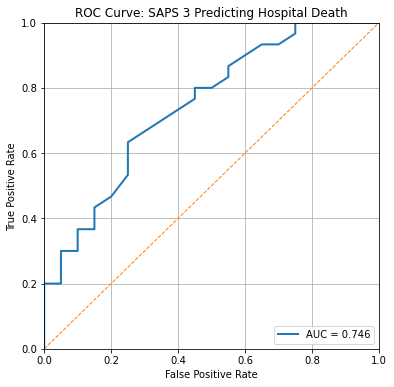

In [20]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: SAPS 3 Predicting Hospital Death")
plt.grid(True)
plt.legend(loc="lower right")
plt.show()

## End of Notebook